In [1]:
import numpy as np
import tensorflow as tf
import gene_data
import configs
import hnn
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2024-12-09 09:56:57.658535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1733709417.680931   15747 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1733709417.687900   15747 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-09 09:56:57.712142: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [343]:
def testloss(name = "LHNN_3DRosenbrock_T150"):
    print(name)

    # name = "LHNN_ellipticpde"
    config = configs.CONFIGS[name] # load the config which records all experiment parameters.
    config["load"] = True
    np.random.seed(config["seed"])
    tf.random.set_seed(config["seed"])

    data = gene_data.get_dataset(**config)
    # arrange data
    train_states = tf.convert_to_tensor( data['train_states'], dtype=tf.float32)
    test_states = tf.convert_to_tensor(data['test_states'], dtype=tf.float32)
    train_timegrads = tf.convert_to_tensor(data['train_timegrads'], dtype=tf.float32)
    test_timegrads = tf.convert_to_tensor(data['test_timegrads'], dtype=tf.float32)

    model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
    model.load_weights(f"/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_3DRosenbrock_sin.weights.h5")


    train_timegrads_hat = model.get_gradient(train_states)
    train_dist = (train_timegrads - train_timegrads_hat)**2 #/ (abs(train_timegrads) + 1)
    test_timegrads_hat = model.get_gradient(test_states)
    test_dist = (test_timegrads - test_timegrads_hat)**2 
    print('Train loss {:.4e} +/- {:.4e}\n test loss {:.4e} +/- {:.4e}'
        .format(tf.reduce_mean(train_dist).numpy(), tf.math.reduce_std(train_dist).numpy()/np.sqrt(train_dist.shape[0]),
                tf.reduce_mean(test_dist).numpy(),  tf.math.reduce_std(test_dist).numpy()/np.sqrt(test_dist.shape[0])))
    

In [328]:
for name in ["LHNN_3DRosenbrock", "LHNN_3DRosenbrock_T100", "LHNN_3DRosenbrock_T150", "LHNN_3DRosenbrock_T250"]:
    testloss(name=name)

LHNN_3DRosenbrock
Successfully loaded data
Train loss 4.0513e-02 +/- 1.8504e-03
 test loss 4.7000e-03 +/- 2.6764e-04
LHNN_3DRosenbrock_T100
Successfully loaded data


Train loss 3.9422e+00 +/- 3.4429e-01
 test loss 6.8121e+00 +/- 3.8052e-01
LHNN_3DRosenbrock_T150
Successfully loaded data
Train loss 1.4727e+00 +/- 8.7210e-02
 test loss 9.0933e-01 +/- 7.2068e-02
LHNN_3DRosenbrock_T250
Successfully loaded data
Train loss 3.9645e+01 +/- 9.0953e-01
 test loss 4.4389e+01 +/- 3.5434e+00


In [340]:
for name in ["LHNN_3DRosenbrock", "LHNN_3DRosenbrock_T100", "LHNN_3DRosenbrock_T150", "LHNN_3DRosenbrock_T250"]:
    testloss(name=name)

LHNN_3DRosenbrock
Successfully loaded data
Train loss 3.8916e+01 +/- 2.8369e+00
 test loss 5.0806e-03 +/- 3.4788e-04
LHNN_3DRosenbrock_T100
Successfully loaded data


Train loss 5.5366e-03 +/- 8.0902e-05
 test loss 1.8426e+02 +/- 1.2569e+01
LHNN_3DRosenbrock_T150
Successfully loaded data
Train loss 8.3143e+00 +/- 7.7191e-01
 test loss 1.0927e-02 +/- 4.0326e-04
LHNN_3DRosenbrock_T250
Successfully loaded data
Train loss 5.0925e+01 +/- 1.2955e+00
 test loss 8.1099e+01 +/- 6.9337e+00


In [342]:
for name in ["LHNN_3DRosenbrock", "LHNN_3DRosenbrock_T100", "LHNN_3DRosenbrock_T150", "LHNN_3DRosenbrock_T250"]:
    testloss(name=name)

LHNN_3DRosenbrock
Successfully loaded data
Train loss 1.9759e+01 +/- 1.2547e+00
 test loss 2.6842e-03 +/- 1.0036e-04
LHNN_3DRosenbrock_T100
Successfully loaded data


Train loss 2.9410e+00 +/- 2.0795e-01
 test loss 5.8768e-01 +/- 7.1753e-02
LHNN_3DRosenbrock_T150
Successfully loaded data
Train loss 4.7005e-03 +/- 4.2604e-05
 test loss 8.3535e-03 +/- 2.8504e-04
LHNN_3DRosenbrock_T250
Successfully loaded data
Train loss 8.4385e+01 +/- 2.6622e+00
 test loss 9.4367e+01 +/- 5.9533e+00


In [335]:
for name in ["LHNN_3DRosenbrock", "LHNN_3DRosenbrock_T100", "LHNN_3DRosenbrock_T150", "LHNN_3DRosenbrock_T250"]:
    testloss(name=name)

LHNN_3DRosenbrock
Successfully loaded data
Train loss 2.2496e-02 +/- 7.8315e-04
 test loss 5.8306e-03 +/- 2.9147e-04
LHNN_3DRosenbrock_T100
Successfully loaded data
Train loss 1.2249e-02 +/- 4.3462e-04
 test loss 3.5002e-02 +/- 1.3283e-03
LHNN_3DRosenbrock_T150
Successfully loaded data
Train loss 9.9677e-03 +/- 1.2136e-04
 test loss 7.7530e-03 +/- 1.8159e-04
LHNN_3DRosenbrock_T250
Successfully loaded data
Train loss 1.5721e-02 +/- 1.7584e-04
 test loss 3.1699e-02 +/- 1.4394e-03


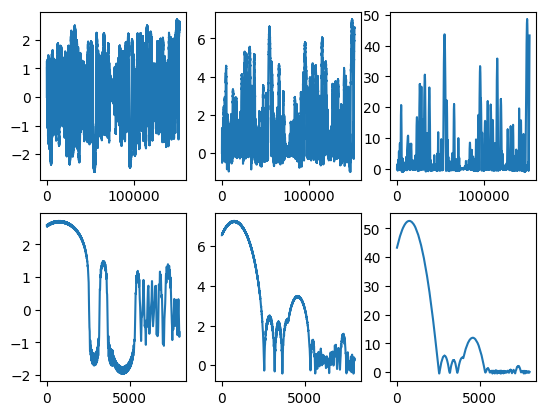

In [273]:

for i in range(3):
    plt.subplot(2,3,i+1)
    plt.plot(data["train_states"][:,i])
for i in range(3):
    plt.subplot(2,3,4+i)
    plt.plot(data["test_states"][:,i])



3.4662358027410924


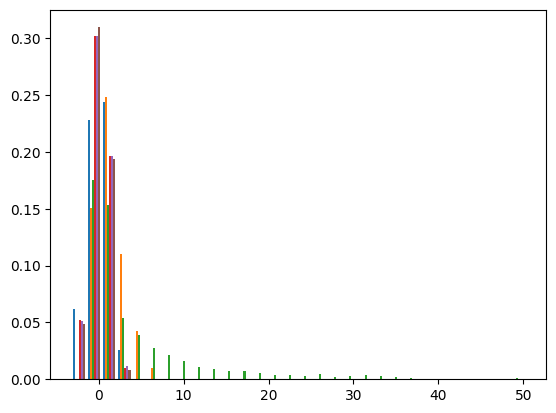

In [237]:
import matplotlib.pyplot as plt
print(np.mean(abs(data["train_timegrads"])))

plt.hist(data["train_states"], density=True, bins=30)
plt.show()

In [238]:
model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_3DRosenbrock_T150_sin.weights.h5")

In [239]:

train_timegrads_hat = model.get_gradient(train_states)
train_dist = (train_timegrads - train_timegrads_hat)**2 #/ (abs(train_timegrads) + 1)
test_timegrads_hat = model.get_gradient(test_states)
test_dist = (test_timegrads - test_timegrads_hat)**2 
print('Train loss {:.4e} +/- {:.4e}\n test loss {:.4e} +/- {:.4e}'
    .format(tf.reduce_mean(train_dist).numpy(), tf.math.reduce_std(train_dist).numpy()/np.sqrt(train_dist.shape[0]),
            tf.reduce_mean(test_dist).numpy(),  tf.math.reduce_std(test_dist).numpy()/np.sqrt(test_dist.shape[0])))

Train loss 1.9176e-02 +/- 6.1887e-04
 test loss 4.0323e-02 +/- 2.6750e-03


In [336]:
import pickle
with open("/home/ycui/Documents/TSRLproject_JPMorgan/data/3DRosenbrock_T100.obj", 'rb') as f:
    data = pickle.load(f)

In [278]:
for name in ["states", "timegrads"]:
    idx = len(data[f"test_{name}"])
    data[f"test_{name}"] = np.concat([data[f"train_{name}"][-idx:], data[f"test_{name}"]], axis=0)
    data[f"train_{name}"] = data[f"train_{name}"][:-idx]

In [281]:
with open("/home/ycui/Documents/TSRLproject_JPMorgan/data/3DRosenbrock_T100.obj", 'wb') as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

In [167]:
def myfun(coords):
    input_dim = len(coords)
    dic1 = np.split(coords,input_dim)
    
    term1 = 0.0
    for ii in np.arange(0,int(input_dim/2)-1,1):
        term1 = term1 + (100.0 * (dic1[ii+1] - dic1[ii]**2)**2 + (1 - dic1[ii])**2) / 20.0
    term2 = 0.0
    for ii in np.arange(int(input_dim/2),input_dim,1):
        term2 = term2 + 1*dic1[ii]**2/2
    H = term1 + term2
    return H

In [170]:
states = np.random.normal(size=10)

In [171]:
import functions

functions.functions("nD_Rosenbrock")(states).numpy() - myfun(states)

array([0.])

In [123]:
def compute_numerical_gradients(model, x, y_true, epsilon=1e-5):
    numerical_gradients = []
    for param in model.trainable_variables:  # 遍历每个可训练参数
        grad = np.zeros_like(param.numpy())  # 初始化梯度数组
        param_value = param.numpy()  # 当前参数值

        # 遍历参数中的每个元素，计算数值梯度
        it = np.nditer(param_value, flags=['multi_index'], op_flags=['readwrite'])
        while not it.finished:
            idx = it.multi_index  # 获取当前元素的索引

            # f(param + epsilon)
            param_value[idx] += epsilon
            param.assign(param_value)  # 暂时更新参数
            loss_plus = loss_obj(y_true, model.get_gradient(x)).numpy()

            # f(param - epsilon)
            param_value[idx] -= 2 * epsilon
            param.assign(param_value)  # 暂时更新参数
            loss_minus = loss_obj(y_true, model.get_gradient(x)).numpy()

            # 恢复原始参数值
            param_value[idx] += epsilon
            param.assign(param_value)

            # 数值梯度公式
            grad[idx] = (loss_plus - loss_minus) / (2 * epsilon)
            it.iternext()
        
        numerical_gradients.append(grad)
    return numerical_gradients

In [124]:
num_grads = compute_numerical_gradients(model, train_states[1:2], train_timegrads[1:2])

In [126]:
for _g, _ng in zip(grads,num_grads):
    print(np.mean((_g-_ng)**2))

0.00247605
0.0
0.0016017343
0.0
0.008449017
0.0
0.004614354


In [59]:
import train
import importlib
importlib.reload(train)
from configs import CONFIGS

In [60]:
config = CONFIGS["LHNN_1DGaussianmixture"] # load the config which records all experiment parameters.
# data = gene_data.get_dataset(**config)
# print("Finished generating the dataset.")
model = train.train(config)

Successfully loaded data
Begin the 0th training epoch:


Train loss 5.9864e-03 +/- 2.0922e-04
 test loss 4.3878e-03 +/- 3.2016e-04
Begin the 1th training epoch:
Train loss 1.0524e-03 +/- 3.4995e-05
 test loss 4.9435e-04 +/- 2.5998e-05
Begin the 2th training epoch:
Train loss 8.5512e-04 +/- 2.3242e-05
 test loss 8.4770e-04 +/- 4.7371e-05
Begin the 3th training epoch:
Train loss 2.5171e-04 +/- 6.9894e-06
 test loss 1.8864e-04 +/- 9.4492e-06
Begin the 4th training epoch:
Train loss 4.6476e-04 +/- 1.1740e-05
 test loss 4.4487e-04 +/- 2.0658e-05
Begin the 5th training epoch:
Train loss 1.8653e-03 +/- 4.6979e-05
 test loss 1.8230e-03 +/- 8.6530e-05
Begin the 6th training epoch:
Train loss 7.2458e-05 +/- 2.2620e-06
 test loss 3.1889e-05 +/- 1.4392e-06
Begin the 7th training epoch:
Train loss 5.9839e-05 +/- 1.9074e-06
 test loss 2.4281e-05 +/- 1.1403e-06
Begin the 8th training epoch:
Train loss 5.0861e-05 +/- 1.6369e-06
 test loss 1.9480e-05 +/- 9.4271e-07
Begin the 9th training epoch:
Train loss 5.0374e-05 +/- 1.4881e-06
 test loss 2.3752e-05 +/- 9

In [61]:
data = gene_data.get_dataset(**config)

Successfully loaded data


In [62]:
# arrange data
train_states = tf.convert_to_tensor(data['train_states'], dtype=tf.float32)
test_states = tf.convert_to_tensor(data['test_states'], dtype=tf.float32)
train_timegrads = tf.convert_to_tensor(data['train_timegrads'], dtype=tf.float32)
test_timegrads = tf.convert_to_tensor(data['test_timegrads'], dtype=tf.float32)

In [63]:
train_timegrads_hat = model.get_gradient(train_states)
train_dist = (train_timegrads - train_timegrads_hat)**2 
test_timegrads_hat = model.get_gradient(test_states)
test_dist = (test_timegrads - test_timegrads_hat)**2
print('Train loss {:.4e} +/- {:.4e}\n test loss {:.4e} +/- {:.4e}'
    .format(tf.reduce_mean(train_dist).numpy(), tf.math.reduce_std(train_dist).numpy()/np.sqrt(train_dist.shape[0]),

            tf.reduce_mean(test_dist).numpy(),  tf.math.reduce_std(test_dist).numpy()/np.sqrt(test_dist.shape[0])))

Train loss 8.1526e-05 +/- 3.2732e-06
 test loss 1.1784e-05 +/- 4.2207e-07


In [64]:
weights = [va.numpy() for va in model.trainable_variables]

In [65]:
for _w in weights:
    print(_w)

[[ 2.45823413e-01  2.07824245e-01 -2.50091881e-01 -5.33072986e-02
   4.84837517e-02  7.63757452e-02 -1.22169413e-01  8.30326825e-02
  -1.61776468e-01 -2.36695170e-01 -1.51748195e-01  1.70040861e-01
   1.46442011e-01  1.39164329e-01  8.21178108e-02  2.66222298e-01
  -2.03978062e-01 -4.51216176e-02 -2.41365910e-01  1.56567767e-01
   2.28742257e-01  2.37346180e-02  2.48609960e-01  1.94126308e-01
  -1.96185052e-01  8.94899890e-02 -2.20420927e-01 -2.01779246e-01
   4.30059843e-02  7.70732388e-02 -1.35414958e-01 -2.05222681e-01
   2.50131711e-02 -2.10506216e-01 -1.34227976e-01  6.05700053e-02
   1.90544546e-01  1.57487348e-01  1.52928889e-01 -1.17538117e-01
   2.01223701e-01 -1.96746632e-01  8.29755813e-02  2.05874145e-01
   2.44862601e-01  1.09731510e-01  1.95284143e-01  1.23065211e-01
   1.39912903e-01  1.46127552e-01 -2.23695233e-01  2.58300006e-01
   1.73355162e-01  2.34421983e-01 -1.67864129e-01  2.71403402e-01
   2.69738525e-01  1.89967796e-01  2.45728835e-01 -2.80407876e-01
  -2.14324

In [66]:
model.save("mymodel.keras")


/home/ycui/.conda/envs/tf/lib/python3.10/site-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [86]:
model.save_weights("mymodel.weights.h5")

In [87]:
model2 = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
model2.load_weights("mymodel.weights.h5")

In [80]:

# model_path = "/home/ycui/Documents/TSRLproject_JPMorgan/models/1DGaussianmixture.keras"
model_path = "mymodel.keras"
model1 = tf.keras.models.load_model(model_path)

In [ ]:
def getloss(model):
    train_timegrads_hat = model.get_gradient(train_states)
    train_dist = (train_timegrads - train_timegrads_hat)**2 
    test_timegrads_hat = model.get_gradient(test_states)
    test_dist = (test_timegrads - test_timegrads_hat)**2
    print('Train loss {:.4e} +/- {:.4e}\n test loss {:.4e} +/- {:.4e}'
        .format(tf.reduce_mean(train_dist).numpy(), tf.math.reduce_std(train_dist).numpy()/np.sqrt(train_dist.shape[0]),
                tf.reduce_mean(test_dist).numpy(),  tf.math.reduce_std(test_dist).numpy()/np.sqrt(test_dist.shape[0])))

getloss(model2)

Train loss 8.1526e-05 +/- 3.2732e-06
 test loss 1.1784e-05 +/- 4.2207e-07


: 

In [56]:
weights_new = [va.numpy() for va in model.trainable_variables]

In [58]:
for _w, _v in zip(weights, weights_new):
    print(np.sum(_w-_v))

0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [77]:
model.hidden_layers[0](train_states) - model1.hidden_layers[0](train_states)

<tf.Tensor: shape=(6416, 100), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

In [78]:
model.call

<bound method HNN.call of <HNN name=hnn_2, built=False>>

In [79]:
model1.call

<bound method HNN.call of <HNN name=hnn_2, built=False>>

In [2]:
def mock_hamiltonian(state):
    """
    A simple quadratic Hamiltonian for testing:
        H = 0.5 * (posi^2 + momen^2)
    """
    position = state[:len(state) // 2]
    momentum = state[len(state) // 2:]
    return 0.5 * tf.reduce_sum(position**2 + momentum**2)

In [1]:
from src.utils import *
import tensorflow as tf
import numpy as np
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.set_visible_devices(gpus[0], "GPU")

2025-01-31 10:19:02.844951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738289942.869350 1779791 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738289942.876857 1779791 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-31 10:19:02.904970: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

# timegrad_fn = get_timegrad_fn(mock_hamiltonian)
state = np.array([1.0, 2.0, 3.0, 4.0])
state = tf.convert_to_tensor(state)

timegrad = timegrad_fn(state)
print(timegrad)
assert timegrad.shape == state.shape

I0000 00:00:1738289951.003905 1779791 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10008 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


NameError: name 'timegrad_fn' is not defined

In [7]:
state

array([1., 2., 3., 4.])